#### 0. Install dependencies

In [1]:
import numpy as np
import h5py
import importlib

from gtda.plotting import plot_point_cloud


import pickle
from pathlib import Path

# Визуализация

In [2]:
samples = {}
train_file = "./data/MNIST3d/train_point_clouds.h5"

with h5py.File(train_file,"r") as hf:
  for key in hf.keys(): # key = id
    group = hf[key]
    label = int(group.attrs["label"])

    if (label not in samples):  # take 1 instance of each digit
      points = group["points"][:] # (N, 3)  x, y, z
      samples[label] = points

      if len(samples) == 10:
        break


In [3]:
# sorting is optional i just think it looks better this way
sorted_samples = dict(sorted(samples.items()))
plot_point_cloud(sorted_samples[0]) # change number in brackets to plot different digits

Точки в облаках расположены достаточно плотно. Внутри цифры полые.

# Нормализация
Согласно документации датасета, все облака точек должны быть нормализованы. Проверим это, собрав статистику по каждой цифре отдельно и по всем цифрам сразу.

In [ ]:
import utils.stat
importlib.reload(utils.stat)

class_stats, global_stats = utils.stat.compute_statistics(train_file)

In [12]:
class_stats

num_points                                      range_x        range_y  \
      num_clouds        mean        std    min    max    mean    std    mean   
label                                                                          
0            479  27806.3674  2404.0861  19050  35400  0.3000  0.000  0.9065   
1            563  13510.6572  2211.8518   9250  26850  0.3000  0.000  0.4898   
2            488  24701.2295  3273.3208  14600  32400  0.3000  0.000  0.9172   
3            493  25364.5030  3462.8836  14550  33550  0.3000  0.000  0.8404   
4            535  21927.7570  2667.0957  14950  28300  0.3000  0.000  0.8257   
5            434  24189.2857  3614.6889  15900  35600  0.3000  0.000  0.9144   
6            501  22882.1357  3531.0587  14450  37300  0.3000  0.000  0.7500   
7            550  20357.0909  2637.8022  13150  27600  0.3001  0.001  0.8112   
8            462  25543.9394  3563.1286  15250  38200  0.3000  0.000  0.7985   
9            495  21867.9798  2837.9709  12100  30600  0.3000  0.000  0.7201   

              range_z          
          std    mean     std  
label                          
0      0.1138  0.9827  0.0532  
1      0.2016  0.9996  0.0087  
2      0.1172  0.9553  0.0883  
3      0.1393  0.9941  0.0288  
4      0.1400  0.9942  0.0266  
5      0.1223  0.9461  0.0928  
6      0.1477  0.9954  0.0284  
7      0.1433  0.9916  0.0366  
8      0.1462  0.9936  0.0342  
9      0.1336  0.9986  0.0126

Наиболее заметное различие наблюдается в количестве точек: цифры 0 и 8 представлены наиболее плотными облаками, в то время как цифра 1 содержит существенно меньше точек.
По пространственным характеристикам все объекты имеют практически идентичный диапазон по оси X, что обусловлено особенностями генерации датасета. В то же время по осям Y и Z наблюдаются выраженные класс-специфичные различия. Цифра 1 характеризуется вытянутостью (относительно узкий диапазон по Y), в то время как цифры 0, 2 и 5 имеют более сбалансированные пропорции. Классы демонстрируют диапазон по Z близкий к 1.0.

In [13]:
global_stats

,mean,std,min,max
num_points,22600.0900,4895.4854,9250.00,38200.0000
range_x,0.3000,0.0003,0.30,0.3158
range_y,0.7915,0.1899,0.15,1.0000
range_z,0.9859,0.0509,0.50,1.0000
label,4.4670,2.8722,0.00,9.0000


# Сэмплирование

In [4]:
import utils.subsampling
importlib.reload(utils.subsampling)

point_clouds, labels = utils.subsampling.subsample_dataset(train_file, max_samples_per_class=50)

Облака содержат очень много точек. Симплициальные комплексы долго считаются и могут не влезать в память. Попробуем сэмплировать точки.

In [5]:
import utils.subsampling
importlib.reload(utils.subsampling)


to_subsample, labels_subsampled = utils.subsampling.subsample_dataset(train_file, max_samples_per_class=100)
subsampled_point_clouds = utils.subsampling.subsample_point_clouds(to_subsample, 5000)

plot_point_cloud(subsampled_point_clouds[0])

# Симплициальные комплексы и диаграммы персистентности

In [ ]:
import utils.persistence
importlib.reload(utils.persistence)

trees, diagrams = utils.persistence.build_diagrams(point_clouds)

Processing clouds: 100%|██████████| 10/10 [00:00<00:00, 681.59it/s]


In [6]:
import utils.persistence
importlib.reload(utils.persistence)

trees_sub, diagrams_sub = utils.persistence.build_diagrams(subsampled_point_clouds)

Processing clouds: 100%|██████████| 1000/1000 [04:17<00:00,  3.88it/s]


## Сохранение и загрузка диаграмм

In [7]:
trees_path = Path("./data/tda/simplex_trees_gudhi.pkl")
diagrams_path = Path("./data/tda/persistence_diagrams_gudhi.pkl")

subsampled_trees_path = Path("./data/tda/subsampled_simplex_trees_gudhi.pkl")
subsampled_diagrams_path = Path("./data/tda/subsampled_persistence_diagrams_gudhi.pkl")

In [8]:
import utils.save_load
importlib.reload(utils.save_load)

utils.save_load.save_tree_diagram(diagrams_path, diagrams, trees_path, trees)
utils.save_load.save_tree_diagram(subsampled_diagrams_path, diagrams_sub, subsampled_trees_path, trees_sub)

Trees saved to data\tda\subsampled_simplex_trees_gudhi.pkl
Diagrams saved to data\tda\subsampled_persistence_diagrams_gudhi.pkl


In [58]:
diagrams_sub[0]

[(2, (0.0014285512054359579, 0.01776547479161851)),
 (2, (0.003931539721831162, 0.010756207619563855)),
 (2, (0.005770202227599776, 0.009304387316369359)),
 (2, (0.008475971646238313, 0.010551224829369462)),
 (2, (0.0058410668814799244, 0.007628864674809888)),
 (2, (0.008830655941001731, 0.010591943941506653)),
 (2, (0.00900367590000405, 0.010474974099756708)),
 (2, (0.00609827892313579, 0.0067996282601697385)),
 (2, (0.00579467951430259, 0.006487146047891158)),
 (2, (0.011789149220748195, 0.01236107152923238)),
 (2, (0.006207227487978006, 0.006746284232140656)),
 (2, (0.0058538388747816535, 0.006379487177275147)),
 (2, (0.006944444444444449, 0.007385544112683436)),
 (2, (0.00831739268152409, 0.008716815437503807)),
 (2, (0.005825460154229376, 0.006219714454372541)),
 (2, (0.010134055629940644, 0.010515767459269805)),
 (2, (0.0009169595448718493, 0.0012234222922504032)),
 (2, (0.004022907508714562, 0.004324662765655454)),
 (2, (0.006043283346671365, 0.006325133775303266)),
 (2, (0.0058

In [9]:
import utils.save_load
importlib.reload(utils.save_load)

diagrams_loaded = utils.save_load.load_object(diagrams_path)
subsampled_diagrams_loaded = utils.save_load.load_object(subsampled_diagrams_path)

Loaded 1000 objects


#### 6. Plot diagrams

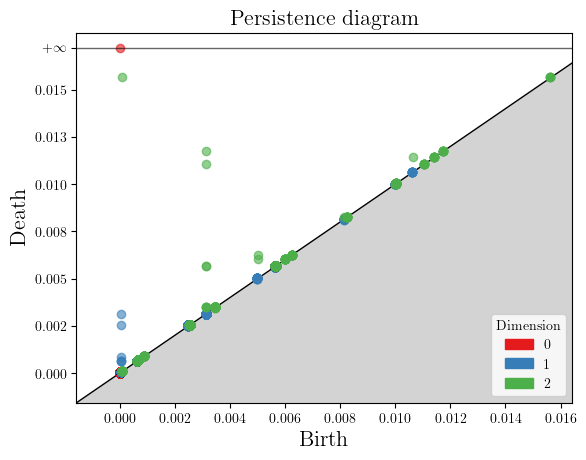

In [ ]:
import utils.plot
importlib.reload(utils.plot)

utils.plot.plot_persistence(diagrams_loaded, labels, 8)

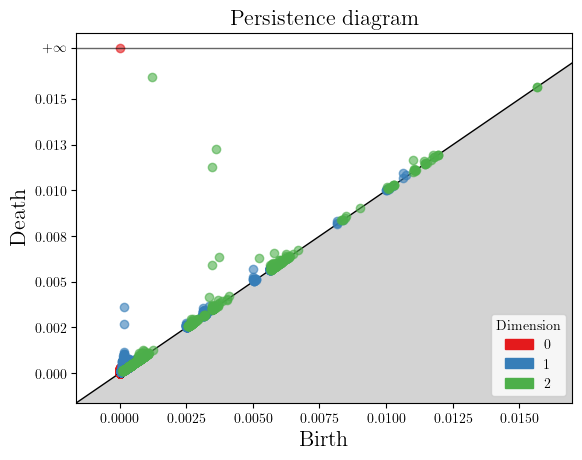

In [15]:
import utils.plot
importlib.reload(utils.plot)

utils.plot.plot_persistance(subsampled_diagrams_loaded, labels_subsampled, 8)

#### 7. Vectorization

In [16]:
import utils.save_load
importlib.reload(utils.save_load)

subsampled_trees_loaded = utils.save_load.load_object(subsampled_trees_path)

Loaded 1000 objects


In [19]:
from tqdm import tqdm

for tree in tqdm(subsampled_trees_loaded, desc="Processing trees"):
  tree.persistence()

Processing trees: 100%|██████████| 1000/1000 [01:57<00:00,  8.53it/s]


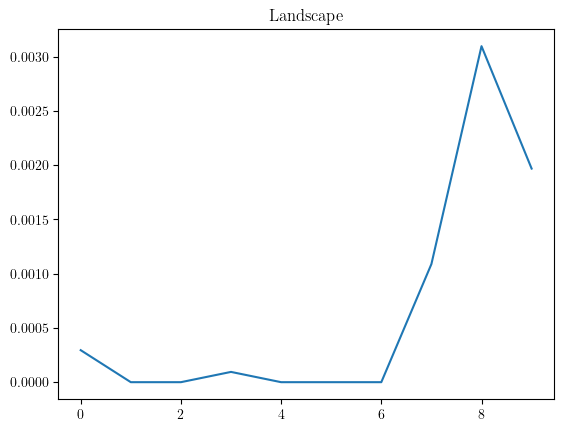

In [87]:
from gudhi.representations import Landscape
from matplotlib import pyplot as plt


LS = Landscape(
    num_landscapes=1,
    resolution=10,
    )

idx = np.where(labels_subsampled == 3)[0][2]
L = LS.fit_transform([subsampled_trees_loaded[idx].persistence_intervals_in_dimension(1)])

plt.plot(L[0][:5000])
plt.title("Landscape")
plt.show()

In [71]:
L

array([[0., 0., 0., ..., 0., 0., 0.]])

In [60]:
L[0].shape

(5000,)

In [ ]:
# переводим в gtda формат
diagrams_sub_gtda = [
    np.array([
        [birth, death, dim]
        for dim, (birth, death) in diag
    ])
    for diag in tqdm(diagrams_sub)
]

100%|██████████| 1000/1000 [00:42<00:00, 23.35it/s]


In [116]:
def top_k(diag, k=50):
    """
    Принимает диаграмму персистентности и оставляет k лучших (наиболее далеких от диагонали) точек.
    """
    pers = diag[:, 1] - diag[:, 0]  # death - birth
    idx = np.argsort(pers)[::-1][:k]    # индексы самых устойчивых объектов
    return diag[idx]

X_h1_top = [top_k(d[d[:, 2] == 1], k=50)    # только h1
            for d in diagrams_sub_gtda]

X = np.stack(X_h1_top)

In [117]:
from gtda.diagrams import PersistenceLandscape

PL = PersistenceLandscape()
landscapes = PL.fit_transform(X)

In [118]:
idx = np.where(labels_subsampled == 0)[0][2]
PL.plot(landscapes, sample=idx)